In [1]:
import igraph as ig
import numpy as np
from scipy.optimize import curve_fit
from tqdm.notebook import tqdm
import networkx as nx

rng = np.random.default_rng()

# Algorithm

In [6]:
def find(ptr, i):
    while ptr[i] != None:
        i = ptr[i]
    return i


def newman_ziff(graph, order, use_tqdm=True):
    neighbours = graph.get_adjlist()
    n = graph.vcount()
    parent = np.full(n, None)
    size = np.zeros(n, dtype="int64")
    data = {"lcc": np.zeros(n), "av_size": np.zeros(n), "n_clusters": np.zeros(n)}
    lcc_size = 0
    n_clusters = 0
    if use_tqdm:
        wrapper = tqdm(range(n))
    else:
        wrapper = range(n)
    for idx in wrapper:
        root = order[idx]
        size[root] = 1
        n_clusters += 1
        for near in neighbours[root]:
            if size[near]:
                near = find(parent, near)
                if near != root:
                    n_clusters -= 1
                    if size[root] < size[near]:
                        size[near] += size[root]
                        parent[root] = near
                        root = near
                    else:
                        size[root] += size[near]
                        parent[near] = root

        if lcc_size < size[root]:
            lcc_size = size[root]

        data["av_size"][idx] = (idx + 1 - lcc_size) / n_clusters
        data["n_clusters"][idx] = n_clusters
        data["lcc"][idx] = lcc_size
    return data


def percolate(n_repeat, graph, use_tqdm=False):
    n_nodes = graph.vcount()
    data = {
        "lcc": np.zeros(n_nodes),
        "av_size": np.zeros(n_nodes),
        "n_clusters": np.zeros(n_nodes),
    }
    if use_tqdm:
        iter = tqdm(range(n_repeat))
    else:
        iter = range(n_repeat)
    for _ in iter:
        order = rng.permutation(n_nodes)
        single_data = newman_ziff(graph, order, use_tqdm=False)
        for key, arr in single_data.items():
            data[key] += arr
    data = {key: arr / n_repeat for key, arr in data.items()}
    return data

# Code

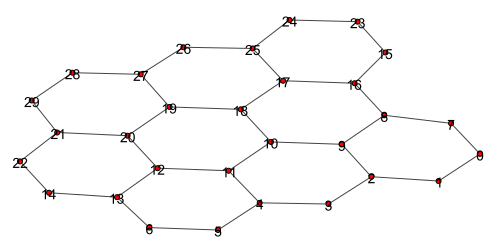

In [7]:
nx_graph = nx.generators.hexagonal_lattice_graph(3, 3)
g = ig.Graph.from_networkx(nx_graph)
ig.plot(g, layout="auto", vertex_size=5, bbox=(500, 250), vertex_label=g.vs.indices)
# ig.Graph.__plot__()

In [8]:
sizes = [10, 20, 40, 80]
final = {"lcc": [], "av_size": [], "n_clusters": []}
nodes = []
for L in tqdm(sizes):
    nx_graph = nx.generators.hexagonal_lattice_graph(L, L)
    g = ig.Graph.from_networkx(nx_graph)
    nodes.append(g.vcount())
    data = percolate(200, g)
    for key, arr in data.items():
        final[key].append(arr)

  0%|          | 0/4 [00:00<?, ?it/s]

In [9]:
%matplotlib qt
import matplotlib.pyplot as plt

In [19]:
for idx, L in enumerate(sizes):
    nodes_added = np.arange(1, nodes[idx] + 1)
    prob = nodes_added / nodes[idx]
    plt.plot(prob, final["av_size"][idx], label=f"L = {L}")

plt.xlim(0.4, 0.8)
plt.axvline(0.697040230, c="k")
plt.legend()

ValueError: x and y must have same first dimension, but have shapes (239,) and (240,)

In [8]:
nx_graph = nx.generators.hexagonal_lattice_graph(200, 200)
g = ig.Graph.from_networkx(nx_graph)
data = percolate(50, g.get_adjlist(), use_tqdm=True)

  0%|          | 0/50 [00:00<?, ?it/s]

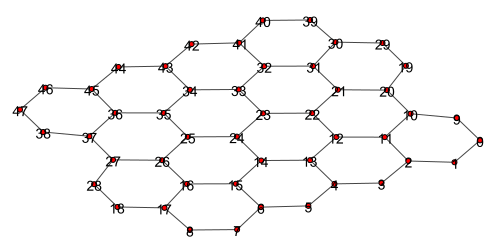

In [9]:
test = nx.generators.hexagonal_lattice_graph(4, 4)
test = ig.Graph.from_networkx(test)
ig.plot(test, layout="auto", vertex_size=5, bbox=(500, 250), vertex_label=g.vs.indices)

In [17]:
def shells(graph, source=23):
    order = 0
    shell_list = []
    shell = graph.neighborhood(source, order=order, mindist=order)
    while shell:
        shell_list.append(shell)
        order += 1
        shell = graph.neighborhood(source, order=order, mindist=order)
    return shell_list

shells(test)

[[23],
 [22, 24, 33],
 [12, 21, 14, 25, 32, 34],
 [11, 13, 20, 31, 15, 26, 35, 41, 43],
 [2, 10, 4, 19, 30, 6, 16, 27, 36, 40, 42, 44],
 [1, 3, 9, 5, 29, 39, 7, 17, 28, 37, 45],
 [0, 8, 18, 38, 46],
 [47]]

In [18]:
order = [el for shell in shells(g, 40000) for el in shell]
# print(len(order), order)
data_loc = newman_ziff(g.get_adjlist(), order, use_tqdm=True)

80800 [40000, 39999, 40001, 40402, 39597, 39998, 39599, 40002, 40401, 40403, 39596, 39598, 39997, 40400, 39600, 40003, 40404, 40803, 40805, 39194, 39595, 39196, 39996, 40399, 39198, 39601, 40004, 40405, 40802, 40804, 40806, 39193, 39195, 39594, 39197, 39995, 40398, 40801, 39199, 39602, 40005, 40406, 40807, 41204, 41206, 41208, 38791, 39192, 38793, 39593, 38795, 39994, 40397, 40800, 38797, 39200, 39603, 40006, 40407, 40808, 41203, 41205, 41207, 41209, 38790, 38792, 39191, 38794, 39592, 38796, 39993, 40396, 40799, 41202, 38798, 39201, 39604, 40007, 40408, 40809, 41210, 41605, 41607, 41609, 41611, 38388, 38789, 38390, 39190, 38392, 39591, 38394, 39992, 40395, 40798, 41201, 38396, 38799, 39202, 39605, 40008, 40409, 40810, 41211, 41604, 41606, 41608, 41610, 41612, 38387, 38389, 38788, 38391, 39189, 38393, 39590, 38395, 39991, 40394, 40797, 41200, 41603, 38397, 38800, 39203, 39606, 40009, 40410, 40811, 41212, 41613, 42006, 42008, 42010, 42012, 42014, 37985, 38386, 37987, 38787, 37989, 39188,

  0%|          | 0/80800 [00:00<?, ?it/s]

In [19]:
nodes_added = np.arange(1, g.vcount() + 1)
prob = nodes_added / g.vcount()
pspan = data["lcc"] / nodes_added
pspan_loc = data_loc["lcc"] / nodes_added

plt.style.use("Physicist")
plt.plot(prob, pspan, lw=2)
plt.plot(prob, pspan_loc, lw=2)
plt.xlim(0.4, 0.8)
plt.axvline(0.697040230, c="k", lw=3)